In [1]:
# Load packages
from pathlib import Path
import os
import re
import sys
import importlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


from kardemumma import *
from kardemumma.proteomedge import fetch_qreps_table

In [2]:

# Skyline data path
skyline_path = "data/MARTHA/DE17501_Martha_results_dotp_charge_16042026.csv"

# Import skyline data (includes column "Isotope Label Type" from Precursor)
skyline_importer = ImportFile(skyline_path)
skyline_data = skyline_importer.import_skyline_file()

The file data/MARTHA/DE17501_Martha_results_dotp_charge_16042026.csv is valid.


In [3]:
get_irt_peptides(skyline_data)

The following peptides are not from Bionosys: SIELAEAK, DLQAQVVESAK, ELDKYGVSDYYK, YGVSDYYK, YGVSDYHK, ISEATDGLSDFLK, NLINNAK, SQTPAEDTVK, ELDKYGVSDYHK, TVEGVKDLQAQVVESAK.
Number of peptides that did not match with Bionosys: 10


Number of iRT peptides: 10
These are the iRT peptides: ['ELDKYGVSDYHK', 'YGVSDYHK', 'NLINNAK', 'TVEGVKDLQAQVVESAK', 'DLQAQVVESAK', 'ISEATDGLSDFLK', 'SQTPAEDTVK', 'SIELAEAK', 'ELDKYGVSDYYK', 'YGVSDYYK']


iRT peptide analysis completed.


['ELDKYGVSDYHK',
 'YGVSDYHK',
 'NLINNAK',
 'TVEGVKDLQAQVVESAK',
 'DLQAQVVESAK',
 'ISEATDGLSDFLK',
 'SQTPAEDTVK',
 'SIELAEAK',
 'ELDKYGVSDYYK',
 'YGVSDYYK']

In [4]:
# Isotope Label Type is added in ImportFile.import_skyline_file() (from Precursor).

# qREPs spike levels
qREPs_spike_levels = pd.read_csv('ratio/DE17501_ratio.csv')

# SDRF
sdrf_path = 'sdrf/sdrf_MARTHA_combined.sdrf.tsv'
sdrf_data = import_sdrf_file(sdrf_path)


QC samples from SDRF: []
Consider removing these before further analysis.


In [5]:
cross_check_skyline_sdrf(skyline_df = skyline_data, sdrf_df = sdrf_data, match_mode="exact")

Skyline files: 862
SDRF files: 861
Overlapping files: 861
Only in Skyline: ['PRM_20251128_MarthaReselection_QC.raw']
Only in SDRF: []


In [6]:
from kardemumma.importer import _suggest_qc_replicate_names

names = skyline_data['File Name'].tolist()

qc_samples = _suggest_qc_replicate_names(names)
print(qc_samples)


['PRM_20251128_MarthaReselection_QC.raw', 'PRM_20251128_MarthaReselection_QC_20251128151944.raw', 'PRM_20251128_MarthaReselection_QC_20251201162324.raw', 'PRM_20251128_MarthaReselection_QC_20251202120251.raw', 'PRM_20251128_MarthaReselection_QC_20251208153500.raw', 'PRM_20251128_MarthaReselection_QC_20251208161323.raw', 'PRM_20251128_MarthaReselection_QC_20251209084653.raw', 'PRM_20251128_MarthaReselection_QC_20251209092514.raw', 'PRM_20251128_MarthaReselection_QC_20251209121038.raw', 'PRM_20251128_MarthaReselection_QC_20251209124901.raw', 'PRM_20251128_MarthaReselection_QC_20251209132508.raw', 'PRM_20251128_MarthaReselection_QC_20251209140116.raw', 'PRM_20251128_MarthaReselection_QC_20251209151815.raw', 'PRM_20251128_MarthaReselection_QC_20251209155637.raw', 'PRM_20251128_MarthaReselection_QC_20251210122424.raw', 'PRM_20251128_MarthaReselection_QC_20251211110209.raw', 'PRM_20251128_MarthaReselection_QC_20251213051215.raw', 'PRM_20251128_MarthaReselection_QC_20251215153457.raw', 'PRM_2

In [7]:
# Find which file is not in the sdrf
not_in_sdrf = set(skyline_data['File Name']) - set(sdrf_data['comment[data file]'])
print(not_in_sdrf)

# Find which file is not in the skyline
not_in_skyline = set(sdrf_data['comment[data file]']) - set(skyline_data['File Name'])
print(not_in_skyline)


{'PRM_20251128_MarthaReselection_QC_20251210122424.raw', 'PRM_20251128_MarthaReselection_QC_20251209124901.raw', 'PRM_20251128_MarthaReselection_QC_20251211110209.raw', 'PRM_20251128_MarthaReselection_QC_20251209084653.raw', 'PRM_20251128_MarthaReselection_QC_20251219032159.raw', 'PRM_20251128_MarthaReselection_QC_20251208153500.raw', 'PRM_20251128_MarthaReselection_QC_20251209151815.raw', 'PRM_20251128_MarthaReselection_QC_20251216162110.raw', 'PRM_20251128_MarthaReselection_QC_20251128151944.raw', 'PRM_20251128_MarthaReselection_QC_20251221134443.raw', 'PRM_20251207_MarthaReselection_Plate_5_C6_20251211114043.raw', 'PRM_20251128_MarthaReselection_QC_20251202120251.raw', 'PRM_20251128_MarthaReselection_QC_20251208161323.raw', 'PRM_20251128_MarthaReselection_QC_20251209121038.raw', 'PRM_20251128_MarthaReselection_QC_20251201162324.raw', 'PRM_20251128_MarthaReselection_QC_20251209140116.raw', 'PRM_20251128_MarthaReselection_QC_20251209155637.raw', 'PRM_20251128_MarthaReselection_QC_2025

In [8]:
# Import and use function from output_test.py to get iRT peptides
iRT_peptides = get_irt_peptides(skyline_data)

print('This is the iRT peptides:')
print(iRT_peptides)

The following peptides are not from Bionosys: SIELAEAK, DLQAQVVESAK, ELDKYGVSDYYK, YGVSDYYK, YGVSDYHK, ISEATDGLSDFLK, NLINNAK, SQTPAEDTVK, ELDKYGVSDYHK, TVEGVKDLQAQVVESAK.
Number of peptides that did not match with Bionosys: 10


Number of iRT peptides: 10
These are the iRT peptides: ['ELDKYGVSDYHK', 'YGVSDYHK', 'NLINNAK', 'TVEGVKDLQAQVVESAK', 'DLQAQVVESAK', 'ISEATDGLSDFLK', 'SQTPAEDTVK', 'SIELAEAK', 'ELDKYGVSDYYK', 'YGVSDYYK']


iRT peptide analysis completed.
This is the iRT peptides:
['ELDKYGVSDYHK', 'YGVSDYHK', 'NLINNAK', 'TVEGVKDLQAQVVESAK', 'DLQAQVVESAK', 'ISEATDGLSDFLK', 'SQTPAEDTVK', 'SIELAEAK', 'ELDKYGVSDYYK', 'YGVSDYYK']


In [9]:
# Checking possible QC samples from Skyline results

qc_samples = skyline_importer.suggest_qc_samples(skyline_data)
skyline_checker = CheckSkylineFile(skyline_path)

# Suggest qc samples
print('This is the qc samples:')
print(f'Number of qc samples: {len(qc_samples)}') 
print(qc_samples)


Possible QC samples: ['PRM_20251128_MarthaReselection_QC', 'PRM_20251128_MarthaReselection_QC_20251128151944', 'PRM_20251128_MarthaReselection_QC_20251201162324', 'PRM_20251128_MarthaReselection_QC_20251202120251', 'PRM_20251128_MarthaReselection_QC_20251208153500', 'PRM_20251128_MarthaReselection_QC_20251208161323', 'PRM_20251128_MarthaReselection_QC_20251209084653', 'PRM_20251128_MarthaReselection_QC_20251209092514', 'PRM_20251128_MarthaReselection_QC_20251209121038', 'PRM_20251128_MarthaReselection_QC_20251209124901', 'PRM_20251128_MarthaReselection_QC_20251209132508', 'PRM_20251128_MarthaReselection_QC_20251209140116', 'PRM_20251128_MarthaReselection_QC_20251209151815', 'PRM_20251128_MarthaReselection_QC_20251209155637', 'PRM_20251128_MarthaReselection_QC_20251210122424', 'PRM_20251128_MarthaReselection_QC_20251211110209', 'PRM_20251128_MarthaReselection_QC_20251213051215', 'PRM_20251128_MarthaReselection_QC_20251215153457', 'PRM_20251128_MarthaReselection_QC_20251216162110', 'PRM_

In [10]:
# Get test samples (exclude QC samples from all replicate names)
skyline_checker = CheckSkylineFile(skyline_path)
test_samples = skyline_checker.get_test_samples(qc_samples, skyline_data)
test_data = skyline_checker.get_test_data(test_samples, skyline_data)
print('This is the test samples:')
print(f'Number of test samples: {len(test_samples)}')

This is the test samples:
Number of test samples: 861


In [ ]:
# Remove QC samples from skyline_data
skyline_data = skyline_importer.remove_qc_samples(skyline_data, qc_samples)


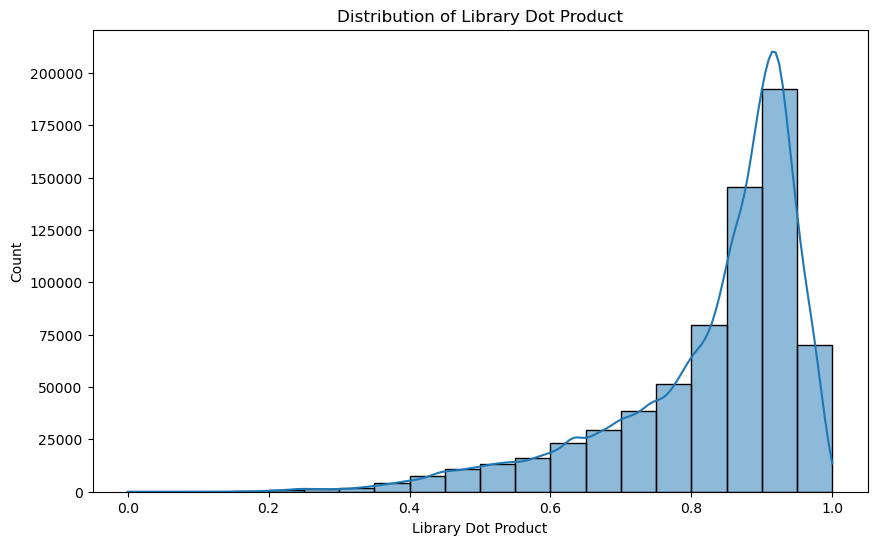

In [11]:
plot_library_dot_product_distribution(skyline_data)

In [12]:
skyline_clean = filter_library_dot_product(skyline_data, threshold=0.6)


In [13]:
# Summarise each peptide to count how many heavy or light signals are present in skyline_pivot
peptide_counts = summarise_peptide_counts(skyline_clean)


In [14]:
report_summary, peptide_list = report_peptide_protein_summary(peptide_counts)

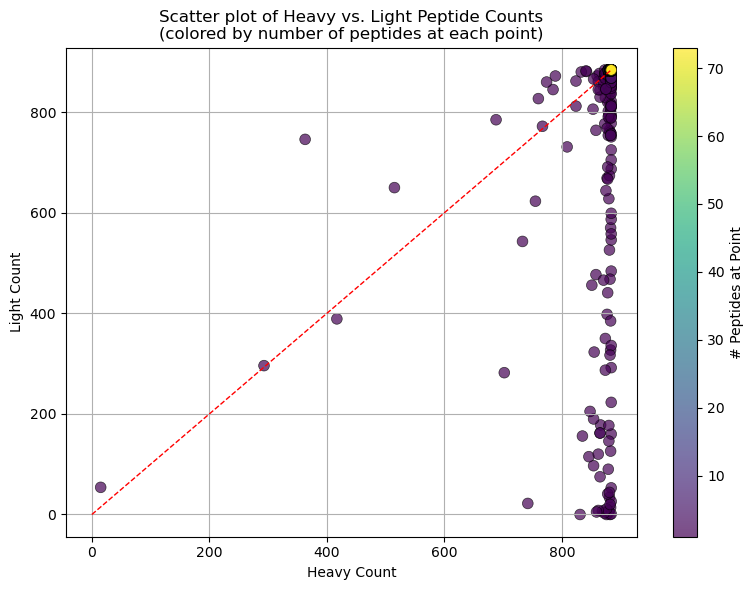

In [15]:
plot_heavy_light_scatter(peptide_counts)

In [16]:
filtered_peptide_counts = filter_peptide_counts(peptide_counts, light_cutoff=700, heavy_cutoff=700)

filtered_peptide_counts.head()


,Protein Name,Peptide,heavy_count,light_count
0,QR0140424_CKB|P12277,GTGGVDTAAVGGVFDVSNADR,884,751
1,QR0140840_SERPINA6|P08185,ITQDAQLK,880,879
2,QR0140840_SERPINA6|P08185,MNTVIAALSR,883,883
3,QR0140840_SERPINA6|P08185,WSAGLTSSQVDLYIPK,884,884
4,QR0221144_ADA2|Q9NZK5,DIPIEVCPISNQVLK,884,868


In [17]:
selected_peptides_report,selected_peptides = report_peptide_protein_summary(filtered_peptide_counts)

In [18]:
from kardemumma.importer import MergeFiles

skyline_merge = MergeFiles(skyline_data, sdrf_data, selected_peptides).merge_files()
skyline_pool = MergeFiles(skyline_data, sdrf_data, selected_peptides).select_pool_data(skyline_merge, col_sample='characteristics[Sample]', sample_value='Pool')

In [19]:
skyline_pool.head()

,Precursor,Replicate,File Name,Peptide Retention Time,Retention Time Calculator Score,Predicted Retention Time,Peptide Sequence,Peptide,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,Protein Name,Isotope Label Type,Precursor Charge,source name,characteristics[Sample],characteristics[Plate]
0,741.3798++ (heavy),PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,14.67,22.09,14.83,AAVYHHFISDGVR,AAVYHHFISDGVR,2.5733E+6,1.1576,NaN,0.8185,QR0280090_C3|P01024,heavy,2,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
1,736.3757++,PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,14.67,22.09,14.83,AAVYHHFISDGVR,AAVYHHFISDGVR,2.5733E+6,1.1576,0.9621,0.8236,QR0280090_C3|P01024,light,2,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
2,539.9587+++ (heavy),PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,13.17,11.12,13.60,AAVYHHFISDGVRK,AAVYHHFISDGVRK,4.8784E+6,1.3330,NaN,0.7337,QR0280090_C3|P01024,heavy,3,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
3,533.9512+++,PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,13.17,11.12,13.60,AAVYHHFISDGVRK,AAVYHHFISDGVRK,4.8784E+6,1.3330,0.8717,0.7391,QR0280090_C3|P01024,light,3,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
4,664.8145++ (heavy),PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,16.45,39.77,16.81,ACIPTGPYPCGK,ACIPTGPYPCGK,1.2571E+6,1.0650,NaN,0.9625,QR3730418_F10|P00742,heavy,2,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1


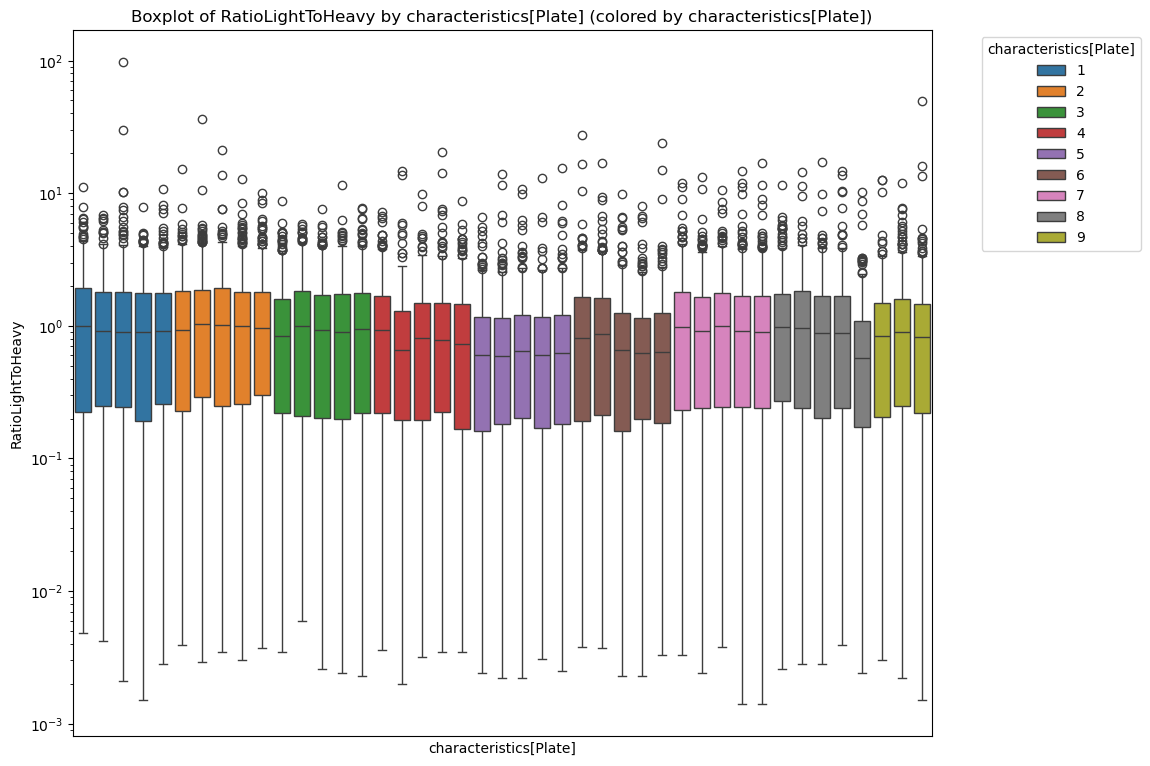

In [20]:
# Plot log_ratio of each sample in boxplot, colored by plate, but x-axis is Replicate, sorted by plate (though x labels are hidden).
plot_pool_boxplot(skyline_pool)


In [21]:
skyline_pool.head()

,Precursor,Replicate,File Name,Peptide Retention Time,Retention Time Calculator Score,Predicted Retention Time,Peptide Sequence,Peptide,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,Protein Name,Isotope Label Type,Precursor Charge,source name,characteristics[Sample],characteristics[Plate]
0,741.3798++ (heavy),PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,14.67,22.09,14.83,AAVYHHFISDGVR,AAVYHHFISDGVR,2.5733E+6,1.1576,NaN,0.8185,QR0280090_C3|P01024,heavy,2,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
1,736.3757++,PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,14.67,22.09,14.83,AAVYHHFISDGVR,AAVYHHFISDGVR,2.5733E+6,1.1576,0.9621,0.8236,QR0280090_C3|P01024,light,2,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
2,539.9587+++ (heavy),PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,13.17,11.12,13.60,AAVYHHFISDGVRK,AAVYHHFISDGVRK,4.8784E+6,1.3330,NaN,0.7337,QR0280090_C3|P01024,heavy,3,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
3,533.9512+++,PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,13.17,11.12,13.60,AAVYHHFISDGVRK,AAVYHHFISDGVRK,4.8784E+6,1.3330,0.8717,0.7391,QR0280090_C3|P01024,light,3,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
4,664.8145++ (heavy),PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,16.45,39.77,16.81,ACIPTGPYPCGK,ACIPTGPYPCGK,1.2571E+6,1.0650,NaN,0.9625,QR3730418_F10|P00742,heavy,2,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1


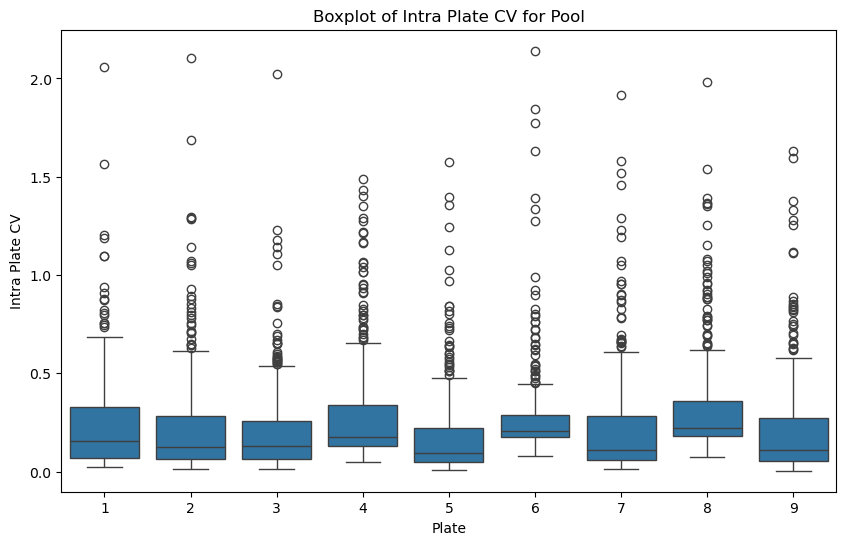

In [22]:
# Calculate intra-plate CV

peptide_plate_stats = calculate_intra_plate_cv(skyline_pool, col_name='characteristics[Plate]')
plot_intra_plate_cv_stats(peptide_plate_stats, col_name='characteristics[Plate]')

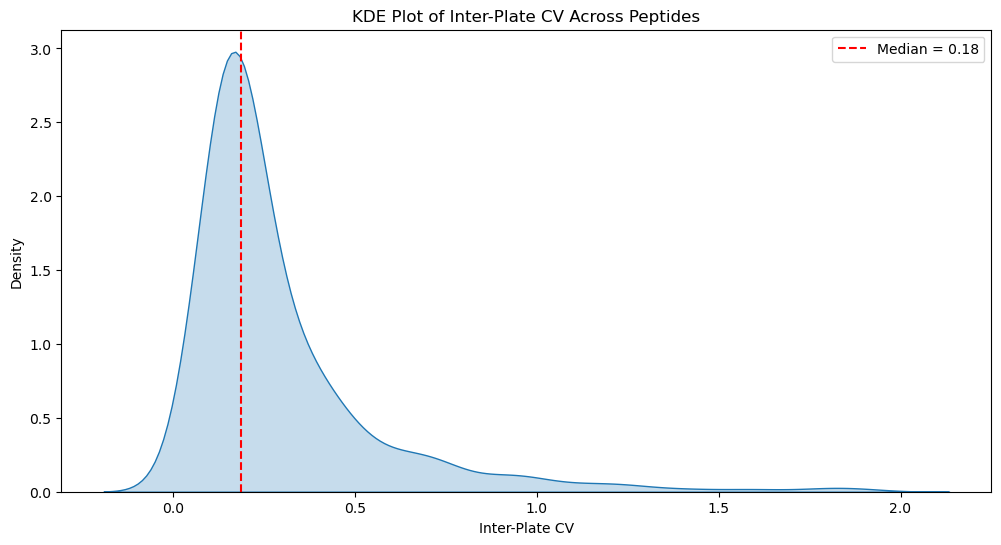

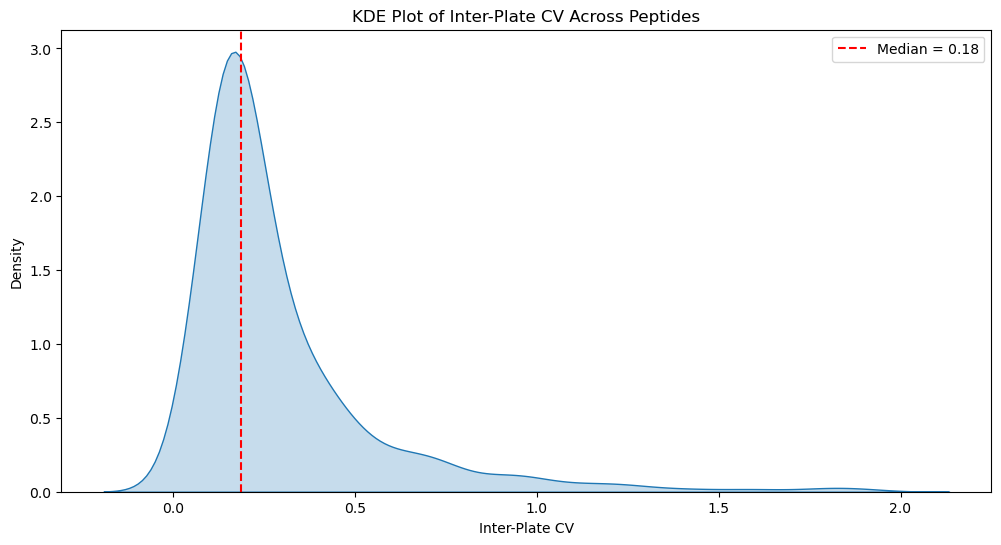

In [23]:
interplate_cv = calculate_inter_plate_cv(peptide_plate_stats)
plot_inter_plate_cv_kde(interplate_cv)

In [24]:
interplate_cv.head()

,Peptide Sequence,grand_mean,between_plate_sd,inter_plate_cv
0,LFINVAPHAR,0.038001,0.002403,0.063237
1,SQCTYSNPEGTVVLACDQAQCR,0.912767,0.064558,0.070728
2,VAQVIIPSTYVPGTTNHDIALLR,0.426258,0.030775,0.072199
3,LLDSLPSDTR,1.734461,0.132915,0.076632
4,FSIEGSYQLEK,0.073040,0.006625,0.090706


In [25]:
# Print interplate_cv froom low to high
print('This is the interplate_cv from low to high:')
print(interplate_cv[interplate_cv['inter_plate_cv'] < 0.1])

This is the interplate_cv from low to high:
          Peptide Sequence  grand_mean  between_plate_sd  inter_plate_cv
0               LFINVAPHAR    0.038001          0.002403        0.063237
1   SQCTYSNPEGTVVLACDQAQCR    0.912767          0.064558        0.070728
2  VAQVIIPSTYVPGTTNHDIALLR    0.426258          0.030775        0.072199
3               LLDSLPSDTR    1.734461          0.132915        0.076632
4              FSIEGSYQLEK    0.073040          0.006625        0.090706
5    DVAPGTLCDVAGWGIVNHAGR    0.014163          0.001312        0.092624


Total number of peptides: 310
Number of peptides with inter-plate CV < 10%: 6
Number of peptides with inter-plate CV < 20%: 172


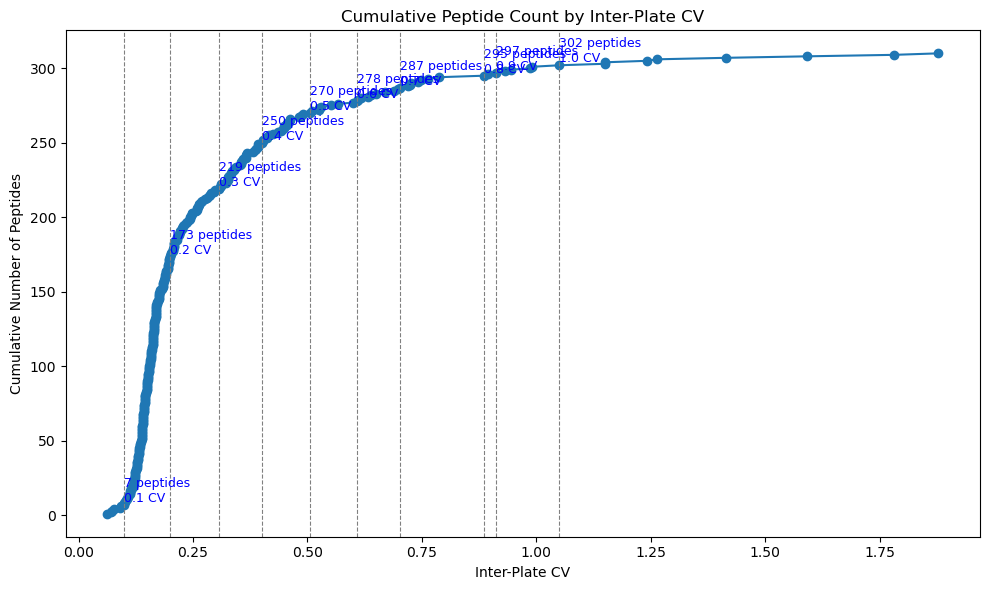

In [26]:
plot_cumulative_peptide_count_by_cv(interplate_cv)

In [27]:
selected_peptides = get_lowest_cv_peptides(interplate_cv, 10)
selected_peptides

array(['LFINVAPHAR', 'SQCTYSNPEGTVVLACDQAQCR', 'VAQVIIPSTYVPGTTNHDIALLR',
       'LLDSLPSDTR', 'FSIEGSYQLEK', 'DVAPGTLCDVAGWGIVNHAGR'], dtype=object)

In [28]:
# Batch/Plate adjustment, correcting for each peptide within each plate (batch) 
# using only peptides in the top 10% lowest inter-plate CV for normalization

pool_selected_df = skyline_pool[skyline_pool['Peptide Sequence'].isin(selected_peptides)]
# Filter pool_data to include only those peptides for normalization calculation
pool_selected_df

,Precursor,Replicate,File Name,Peptide Retention Time,Retention Time Calculator Score,Predicted Retention Time,Peptide Sequence,Peptide,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,Protein Name,Isotope Label Type,Precursor Charge,source name,characteristics[Sample],characteristics[Plate]
72,725.6928+++ (heavy),PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,23.56,101.91,23.78,DVAPGTLCDVAGWGIVNHAGR,DVAPGTLCDVAGWGIVNHAGR,6.2704E+4,0.0207,NaN,0.8192,QR5000033_CFD|P00746,heavy,3,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
73,722.3567+++,PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,23.56,101.91,23.78,DVAPGTLCDVAGWGIVNHAGR,DVAPGTLCDVAGWGIVNHAGR,6.2704E+4,0.0207,0.7940,0.8043,QR5000033_CFD|P00746,light,3,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
124,654.8317++ (heavy),PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,19.73,69.34,20.13,FSIEGSYQLEK,FSIEGSYQLEK,9.7787E+4,0.1027,NaN,0.9461,QR5000085_SERPINA5|P05154,heavy,2,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
125,650.8246++,PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,19.73,69.34,20.13,FSIEGSYQLEK,FSIEGSYQLEK,9.7787E+4,0.1027,0.8377,0.8111,QR5000085_SERPINA5|P05154,light,2,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
286,383.2252+++ (heavy),PRM_20251128_MarthaReselection_Plate_1_B2,PRM_20251128_MarthaReselection_Plate_1_B2.raw,18.03,49.05,17.85,LFINVAPHAR,LFINVAPHAR,2.7256E+4,0.0353,NaN,0.9624,QR5000237_ADAMTS13|Q76LX8,heavy,3,PRM_20251128_MarthaReselection_Plate_1_B2,Pool,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26343,558.7984++,PRM_20251218_MarthaReselection_Plate_9_H12,PRM_20251218_MarthaReselection_Plate_9_H12.raw,18.36,48.53,17.79,LLDSLPSDTR,LLDSLPSDTR,3.0527E+7,1.8594,0.9772,0.9350,QR4370306_SERPING1|P05155,light,2,PRM_20251218_MarthaReselection_Plate_9_H12,Pool,9
26482,852.0380+++ (heavy),PRM_20251218_MarthaReselection_Plate_9_H12,PRM_20251218_MarthaReselection_Plate_9_H12.raw,19.06,59.68,19.05,SQCTYSNPEGTVVLACDQAQCR,SQCTYSNPEGTVVLACDQAQCR,1.2127E+5,0.8888,NaN,0.9525,QR5000083_CPN2|P22792,heavy,3,PRM_20251218_MarthaReselection_Plate_9_H12,Pool,9
26483,848.7019+++,PRM_20251218_MarthaReselection_Plate_9_H12,PRM_20251218_MarthaReselection_Plate_9_H12.raw,19.06,59.68,19.05,SQCTYSNPEGTVVLACDQAQCR,SQCTYSNPEGTVVLACDQAQCR,1.2127E+5,0.8888,0.9369,0.9145,QR5000083_CPN2|P22792,light,3,PRM_20251218_MarthaReselection_Plate_9_H12,Pool,9
26554,830.1314+++ (heavy),PRM_20251218_MarthaReselection_Plate_9_H12,PRM_20251218_MarthaReselection_Plate_9_H12.raw,24.73,107.11,24.37,VAQVIIPSTYVPGTTNHDIALLR,VAQVIIPSTYVPGTTNHDIALLR,1.2385E+5,0.4384,NaN,0.8868,QR4160204_F7|P08709,heavy,3,PRM_20251218_MarthaReselection_Plate_9_H12,Pool,9


In [29]:
plate_factor_table, conversion_factors, model = get_plate_conversion_factors(pool_selected_df, col_plate='characteristics[Plate]', log_transform=True  )

In [30]:
plate_factor_table

,characteristics[Plate],plate_median,correction_factor
0,1,-1.905369,1.139587
1,2,-2.246303,0.966625
2,3,-1.685390,1.288326
3,4,-1.821802,1.191860
4,5,-1.787633,1.214642
5,6,-1.778905,1.220601
6,7,-1.713083,1.267500
7,8,-1.864443,1.164602
8,9,-1.801437,1.205334


In [31]:
conversion_factors

{'1': 1.139586732342153,
 '2': 0.9666251292307191,
 '3': 1.2883263401672571,
 '4': 1.1918600085401956,
 '5': 1.2146416602764194,
 '6': 1.2206011690688392,
 '7': 1.2675002600665493,
 '8': 1.1646016965097268,
 '9': 1.205333504699401}

In [34]:
skyline_merge_adj

,Precursor,Replicate,File Name,Peptide Retention Time,Retention Time Calculator Score,Predicted Retention Time,Peptide Sequence,Peptide,Normalized Area,RatioLightToHeavy,Ratio Dot Product,Library Dot Product,Protein Name,Isotope Label Type,Precursor Charge,source name,characteristics[Sample],characteristics[Plate],Plate
0,488.2589++,PRM_20251128_MarthaReselection_QC,PRM_20251128_MarthaReselection_QC.raw,13.82,18.77,14.46,ISASAEELR,ISASAEELR,1.6751E+7,1.1390,0.9811,0.9736,QR0260124_APOA4|P06727,light,2,NaN,NaN,NaN,NaN
1,488.2589++,PRM_20251128_MarthaReselection_QC_20251128151944,PRM_20251128_MarthaReselection_QC_202511281519...,13.89,18.77,14.46,ISASAEELR,ISASAEELR,1.3198E+7,1.2053,0.9815,0.9770,QR0260124_APOA4|P06727,light,2,NaN,NaN,NaN,NaN
2,488.2589++,PRM_20251128_MarthaReselection_Plate_1_F4,PRM_20251128_MarthaReselection_Plate_1_F4.raw,13.87,18.77,14.46,ISASAEELR,ISASAEELR,2.8591E+7,2.3938,0.9891,0.9722,QR0260124_APOA4|P06727,light,2,PRM_20251128_MarthaReselection_Plate_1_F4,MRTH,1,1
3,488.2589++,PRM_20251128_MarthaReselection_Plate_1_B6,PRM_20251128_MarthaReselection_Plate_1_B6.raw,13.97,18.77,14.46,ISASAEELR,ISASAEELR,2.9292E+7,2.3725,0.9782,0.9759,QR0260124_APOA4|P06727,light,2,PRM_20251128_MarthaReselection_Plate_1_B6,MRTH,1,1
4,488.2589++,PRM_20251128_MarthaReselection_Plate_1_A3,PRM_20251128_MarthaReselection_Plate_1_A3.raw,13.93,18.77,14.46,ISASAEELR,ISASAEELR,1.2654E+7,1.4107,0.9916,0.9820,QR0260124_APOA4|P06727,light,2,PRM_20251128_MarthaReselection_Plate_1_A3,MRTH,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548075,521.3202++ (heavy),PRM_20251218_MarthaReselection_Plate_9_A3,PRM_20251218_MarthaReselection_Plate_9_A3.raw,25.53,111.28,24.83,TLAFPLTIR,TLAFPLTIR,6.1168E+4,0.3779,NaN,0.9056,QR7000010_PROCR|Q9UNN8,heavy,2,PRM_20251218_MarthaReselection_Plate_9_A3,MRTH,9,9
548076,521.3202++ (heavy),PRM_20251218_MarthaReselection_Plate_9_G6,PRM_20251218_MarthaReselection_Plate_9_G6.raw,25.54,111.28,24.83,TLAFPLTIR,TLAFPLTIR,1.1438E+5,0.7279,NaN,0.9041,QR7000010_PROCR|Q9UNN8,heavy,2,PRM_20251218_MarthaReselection_Plate_9_G6,CHAPS,9,9
548077,521.3202++ (heavy),PRM_20251218_MarthaReselection_Plate_9_C8,PRM_20251218_MarthaReselection_Plate_9_C8.raw,25.45,111.28,24.83,TLAFPLTIR,TLAFPLTIR,1.4815E+5,0.9598,NaN,0.8651,QR7000010_PROCR|Q9UNN8,heavy,2,PRM_20251218_MarthaReselection_Plate_9_C8,CHAPS,9,9
548078,521.3202++ (heavy),PRM_20251218_MarthaReselection_Plate_9_B7,PRM_20251218_MarthaReselection_Plate_9_B7.raw,25.54,111.28,24.83,TLAFPLTIR,TLAFPLTIR,7.2499E+4,0.5697,NaN,0.9182,QR7000010_PROCR|Q9UNN8,heavy,2,PRM_20251218_MarthaReselection_Plate_9_B7,CHAPS,9,9


In [33]:


# Use the adjust_ratio_by_plate function above to add RatioLightToHeavy_adj to skyline_merge
# First, construct a Plate column of the correct type for the function
skyline_merge_adj = skyline_merge.copy()
# Make sure 'Plate' column exists and matches conversion_factors keys
skyline_merge_adj['Plate'] = skyline_merge_adj['characteristics[Plate]']

skyline_merge_adj['Plate']
# skyline_merge_adj = adjust_ratio_by_plate(skyline_merge_adj, conversion_factors)


0         NaN
1         NaN
2           1
3           1
4           1
         ... 
548075      9
548076      9
548077      9
548078      9
548079    NaN
Name: Plate, Length: 548080, dtype: object

In [ ]:
# From skyline_merge_adj, filter to pool samples
pool_data_adj = skyline_merge_adj[skyline_merge_adj['characteristics[Sample]'] == 'Pool'].copy()

pool_data_adj.head()


In [ ]:
plot_pool_boxplot(pool_data_adj)

In [ ]:
plot_pool_boxplot(pool_data_adj, col_ratio='RatioLightToHeavy_adj')

# Calculate absolute quantification

In [ ]:

# Add new column call qRePS which is the string before _ in Protein Name col
skyline_merge_adj['qRePS'] = skyline_merge_adj['Protein Name'].str.split('_').str[0]

In [ ]:
# Merge qREPs_spike_levels, to skyline_merge_adj by qRePs
skyline_merge_adj = pd.merge(skyline_merge_adj, qREPs_spike_levels, on=['qRePS'], how='left')
# Add new column call qRePs which is the string before _ in Protein Name col

# Add new column called Protein conc [pmol] which is equal to RatioLightToHeavy_adj * Amount Per well [pmol]
skyline_merge_adj['Protein conc [pmol]'] = skyline_merge_adj['RatioLightToHeavy_adj'] * skyline_merge_adj['Amount per well [pmol]']

# Round Protein conc [pmol] to 4 decimal places
skyline_merge_adj['Protein conc [pmol]'] = skyline_merge_adj['Protein conc [pmol]'].round(4)


In [ ]:
skyline_merge_adj.head()

In [ ]:
# Export wide format for qREPs


# Select columns to export
export_cols = ['Replicate', 'Peptide Sequence', 'Protein Name', 'qRePS', 'Protein conc [pmol]']

# Pivot the dataframe to wide format
skyline_merge_adj_wide = skyline_merge_adj.pivot(
    index=['qRePS', 'Peptide Sequence', 'Protein Name'],
    columns='Replicate',
    values='Protein conc [pmol]'
)

# Export to csv status
# skyline_merge_adj_wide.to_csv('export/MARTHA_conc_normalized.csv', index=True)


